# EDA — Metro Línea 1

**Dataset crudo:** `data_processed/raw/metro_l1_hora.parquet`
**Origen:** 12 Excel mensuales ATU (Validaciones L1)
**Periodo:** 2025 · **Grano crudo:** estación × fecha × hora × **tarifa**
**Guía:** `deliveries/week07/code/eda/eda_transmilenio.ipynb`

| Bloque | Columnas |
|--------|----------|
| Demanda | `validaciones` |
| Estación | `estacion` |
| Tarifa | `tipo_tarifa`, `intervalo` |
| Temporal | `fecha`, `hora` |


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RAIZ = Path.cwd().resolve().parents[1]
RAW = RAIZ / "data_processed" / "raw"
CLEAN = RAIZ / "data_processed" / "clean"
FIGS = RAIZ / "docs" / "images"
CLEAN.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

ANIO = 2025
UMBRAL_COBERTURA = 90
DIAS = ["LUN", "MAR", "MIÉ", "JUE", "VIE", "SÁB", "DOM"]
ORDEN_DIAS = DIAS

FERIADOS_PERU = {
    "2025-01-01": "Anio Nuevo", "2025-04-17": "Jueves Santo", "2025-04-18": "Viernes Santo",
    "2025-05-01": "Dia del Trabajo", "2025-06-29": "San Pedro y San Pablo",
    "2025-07-29": "Fiestas Patrias", "2025-08-30": "Santa Rosa de Lima",
    "2025-10-08": "Combate de Angamos", "2025-11-01": "Todos los Santos",
    "2025-12-08": "Inmaculada Concepcion", "2025-12-25": "Navidad",
}

MAPA_SENTIDO = {
    "NS": ("NS", "N->S"), "SN": ("NS", "S->N"),
    "NORTE-SUR": ("NS", "N->S"), "SUR-NORTE": ("NS", "S->N"),
    "OE": ("EO", "E->O"), "EO": ("EO", "O->E"),
    "OESTE-ESTE": ("EO", "E->O"), "ESTE-OESTE": ("EO", "O->E"),
    "IDA": ("NS", "N->S"), "VUELTA": ("NS", "S->N"),
    "N->S": ("NS", "N->S"), "S->N": ("NS", "S->N"),
    "E->O": ("EO", "E->O"), "O->E": ("EO", "O->E"),
    "N-S": ("NS", "N->S"), "S-N": ("NS", "S->N"),
}

COLOR = "#2e7d32"
SISTEMA = "metro_l1"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "figure.autolayout": True,
})
sns.set_style("whitegrid")


def guardar_fig(nombre: str) -> None:
    destino = FIGS / nombre
    plt.savefig(destino, bbox_inches="tight")
    plt.show()  # inline en la celda + archivo en docs/images
    plt.close()
    print(f"  [figura] {destino.relative_to(RAIZ)}")


def anadir_calendario(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.to_datetime(df["fecha"], errors="coerce")
    out = df.copy()
    out["fecha"] = f.dt.normalize()
    out["anio"] = f.dt.year.astype("Int16")
    out["mes"] = f.dt.month.astype("Int8")
    dow = f.dt.dayofweek
    out["dia_semana"] = [DIAS[int(i)] if pd.notna(i) else None for i in dow]
    out["tipo_dia"] = np.select(
        [dow.isna(), dow <= 4, dow == 5, dow == 6],
        [None, "LAB", "SAB", "DOM"], default=None,
    )
    out["semana_iso"] = f.dt.isocalendar().week.astype("Int16")
    clave = out["fecha"].dt.strftime("%Y-%m-%d")
    out["feriado"] = clave.map(FERIADOS_PERU)
    out["es_feriado"] = out["feriado"].notna()
    return out


def ids_texto(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = (out[c].astype("string").str.replace(r"\.0$", "", regex=True).str.strip())
    return out


def normalizar_sentido(df: pd.DataFrame, col: str = "sentido") -> pd.DataFrame:
    out = df.copy()
    bruto = out[col].astype("string").str.strip().str.upper()
    par = bruto.map(MAPA_SENTIDO)
    out["sentido_norm"] = par.map(lambda t: t[1] if isinstance(t, tuple) else None)
    out["eje"] = par.map(lambda t: t[0] if isinstance(t, tuple) else None)
    out["sentido_crudo"] = bruto
    return out


def marcar_franja(hora: pd.Series) -> pd.Series:
    return pd.cut(
        hora.astype(int),
        bins=[-1, 5, 9, 15, 20, 24],
        labels=["madrugada", "pico_am", "valle", "pico_pm", "noche"],
    )


def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return float(q1 - k * iqr), float(q3 + k * iqr), float(q1), float(q3), float(iqr)


print(f"Sistema: {SISTEMA}")
print(f"RAW  : {RAW}")
print(f"CLEAN: {CLEAN}")


Sistema: metro_l1
RAW  : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data_processed/raw
CLEAN: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data_processed/clean


## 1. Carga del dataset crudo


In [17]:
ruta = RAW / "metro_l1_hora.parquet"
if not ruta.exists():
    raise FileNotFoundError(f"Falta {ruta}. Ejecuta prepare_parquet.py --anio {ANIO}")
df = pd.read_parquet(ruta)
print(f"Filas: {len(df):,} | Columnas: {list(df.columns)}")
df.head()


Filas: 341,640 | Columnas: ['fecha', 'estacion', 'hora', 'intervalo', 'tipo_tarifa', 'validaciones']


,fecha,estacion,hora,intervalo,tipo_tarifa,validaciones
0,2025-01-01,Angamos,5,5-6 h,Adulto,60.0
1,2025-01-01,Angamos,5,5-6 h,Universitario,0.0
2,2025-01-01,Angamos,6,6-7 h,Adulto,262.0
3,2025-01-01,Angamos,6,6-7 h,Universitario,0.0
4,2025-01-01,Angamos,7,7-8 h,Adulto,447.0


## 2. Inspección inicial


In [18]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_%": (100 * df.isna().mean()).round(2),
    "unicos": df.nunique(dropna=False),
})
print(info.to_string())
df[["validaciones"]].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T


                       dtype  nulos  nulos_%  unicos
fecha         datetime64[us]      0      0.0     365
estacion                 str      0      0.0      26
hora                   Int16      0      0.0      18
intervalo                str      0      0.0      18
tipo_tarifa           string      0      0.0       2
validaciones         float64      0      0.0    7094


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
validaciones,341640.0,589.839852,982.189223,0.0,0.0,0.0,32.0,148.0,779.0,2224.0,5062.0,11632.0


## 3. Limpieza

### 3.1 Calendario e IDs; total sin tarifa


In [19]:
df = anadir_calendario(df)
df = ids_texto(df, ["estacion"])
df["hora"] = pd.to_numeric(df["hora"], errors="coerce").astype("Int16")
df["validaciones"] = pd.to_numeric(df["validaciones"], errors="coerce")
antes = len(df)
df["era_celda_vacia"] = df["validaciones"].isna()
n_na = int(df["era_celda_vacia"].sum())
n_zero_escritos = int((df["validaciones"] == 0).sum())
df["validaciones"] = pd.to_numeric(df["validaciones"], errors="coerce").fillna(0)
df = df[df["validaciones"] >= 0].copy()  # conserva ceros; NA→0+flag
print(f"NA→0+flag: {n_na:,} | ceros escritos: {n_zero_escritos:,} | filas panel={len(df):,}")
print(f"con tarifa limpio: {len(df):,} (de {antes:,})")

metro_tot = (df.groupby(
    ["fecha","anio","mes","dia_semana","tipo_dia","semana_iso","feriado","es_feriado","estacion","hora"],
    as_index=False, dropna=False)["validaciones"].sum())
print(f"total estación-hora: {len(metro_tot):,} | estaciones={metro_tot['estacion'].nunique()} | días={metro_tot['fecha'].nunique()}")
print(f"tipo_dia: {sorted(df['tipo_dia'].dropna().unique().tolist())}")
print(f"tarifas: {df['tipo_tarifa'].dropna().unique().tolist()}")


NA→0+flag: 0 | ceros escritos: 34,277 | filas panel=341,640
con tarifa limpio: 341,640 (de 341,640)
total estación-hora: 170,820 | estaciones=26 | días=365
tipo_dia: ['DOM', 'LAB', 'SAB']
tarifas: ['Adulto', 'Universitario']


### 3.2 Cobertura (debería ser 100%)


In [20]:
dias_esperados = pd.date_range(f"{ANIO}-01-01", f"{ANIO}-12-31").normalize().nunique()
cob = (metro_tot.groupby("estacion")["fecha"].nunique().rename("dias_con_datos").reset_index())
cob["dias_esperados"] = dias_esperados
cob["pct_cobertura"] = (100 * cob["dias_con_datos"] / dias_esperados).round(1)
cob["fiable"] = cob["pct_cobertura"] >= UMBRAL_COBERTURA
print(f"Fiables: {cob['fiable'].sum()}/{len(cob)} | min cobertura={cob['pct_cobertura'].min()}")
print(cob.sort_values("pct_cobertura").head().to_string(index=False))


Fiables: 26/26 | min cobertura=100.0
estacion  dias_con_datos  dias_esperados  pct_cobertura  fiable
 Angamos             365             365          100.0    True
Atocongo             365             365          100.0    True
Ayacucho             365             365          100.0    True
 Bayóvar             365             365          100.0    True
 Cabitos             365             365          100.0    True


### 3.3 Aviso sobre tarifa universitaria en domingos

El archivo no trae `Universitario` los domingos → el domingo **subestima** un poco
la demanda real si se usa el desglose tarifario. Para totales usar `metro_tot`.


In [21]:
cruzado = pd.crosstab(df["tipo_dia"], df["tipo_tarifa"])
print(cruzado.to_string())
dom_univ = df[(df["tipo_dia"]=="DOM") & (df["tipo_tarifa"]=="Universitario")]["validaciones"].sum()
print(f"Universitario en DOM: {dom_univ:,.0f}")


tipo_tarifa  Adulto  Universitario
tipo_dia                          
DOM           24336          24336
LAB          122148         122148
SAB           24336          24336
Universitario en DOM: 1


## 4. Feature engineering (sobre total estación-hora)


In [22]:
d = metro_tot.copy()
d["era_celda_vacia"] = False  # L1 no trae NA en raw; flag uniforme
d["franja"] = marcar_franja(d["hora"])
d["log_val"] = np.log1p(d["validaciones"])
diario = (d.groupby(["estacion","fecha"], as_index=False)["validaciones"].sum()
          .rename(columns={"validaciones":"val_dia"}))
lo, hi, q1, q3, iqr = iqr_bounds(diario["val_dia"])
diario["es_outlier_iqr"] = (diario["val_dia"] < lo) | (diario["val_dia"] > hi)
d = d.merge(diario[["estacion","fecha","es_outlier_iqr"]], on=["estacion","fecha"], how="left")
print(f"IQR estación-día [{lo:,.0f},{hi:,.0f}] outliers={diario['es_outlier_iqr'].mean():.2%}")


IQR estación-día [-6,519,43,478] outliers=11.02%


## 5. Outliers (IQR) — ¿borrarlos?

**Decisión: NO eliminarlos del dataset limpio.** En demanda de transporte los
valores fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR] suelen ser **picos reales**
(días de hub, eventos, punta acumulada). Borrar outliers sesgaría justo la cola
que un modelo de aforo/espera necesita aprender.

Sí los **marcamos** (`es_outlier_iqr`) para inspeccionarlos, estratificar el
análisis y, si hace falta, usar `log1p` en modelado.


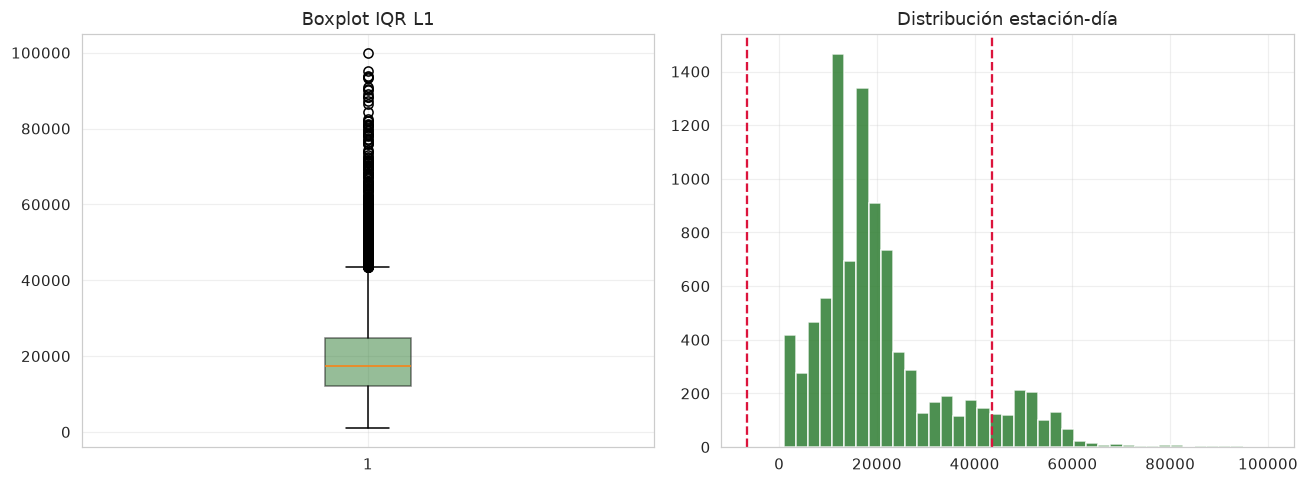

  [figura] docs/images/eda_l1_outliers_iqr.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].boxplot(diario["val_dia"], showfliers=True, patch_artist=True,
                boxprops=dict(facecolor=COLOR, alpha=0.5))
axes[0].set_title("Boxplot IQR L1")
axes[1].hist(diario["val_dia"], bins=40, color=COLOR, alpha=0.85)
axes[1].axvline(lo, color="crimson", ls="--"); axes[1].axvline(hi, color="crimson", ls="--")
axes[1].set_title("Distribución estación-día")
guardar_fig("eda_l1_outliers_iqr.png")


## 6. Análisis

### 6.1 Univariado y serie


Total: 201,512,887


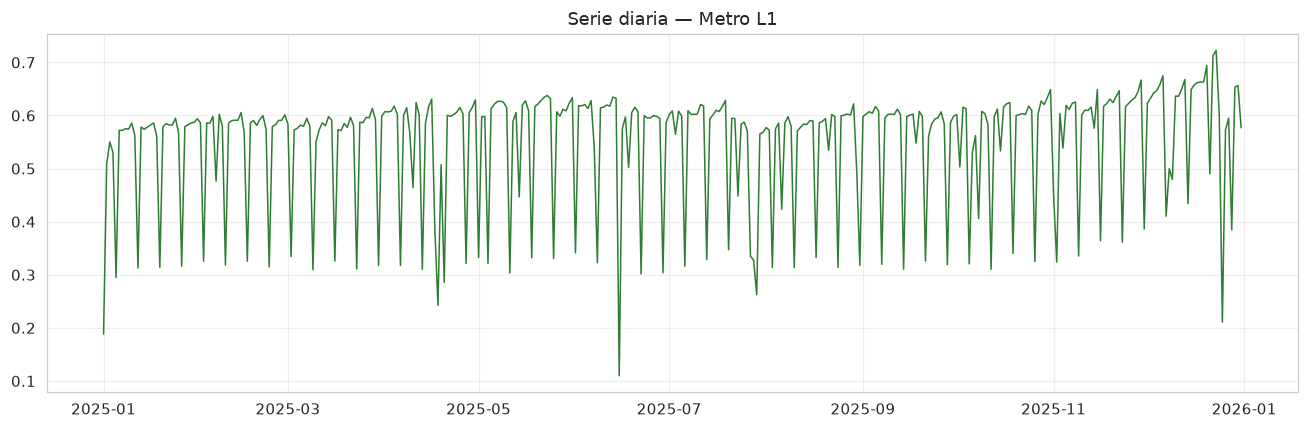

  [figura] docs/images/eda_l1_serie_diaria.png


In [24]:
print(f"Total: {d['validaciones'].sum():,.0f}")
serie = d.groupby("fecha")["validaciones"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie.index, serie.values/1e6, color=COLOR, lw=1)
ax.set_title("Serie diaria — Metro L1")
guardar_fig("eda_l1_serie_diaria.png")


### 6.2 Horario, día de semana, estaciones


hora
18    1810.0
17    1663.0
7     1625.0
19    1617.0
8     1517.0
06-10h 31.4% | 16-20h 35.9%


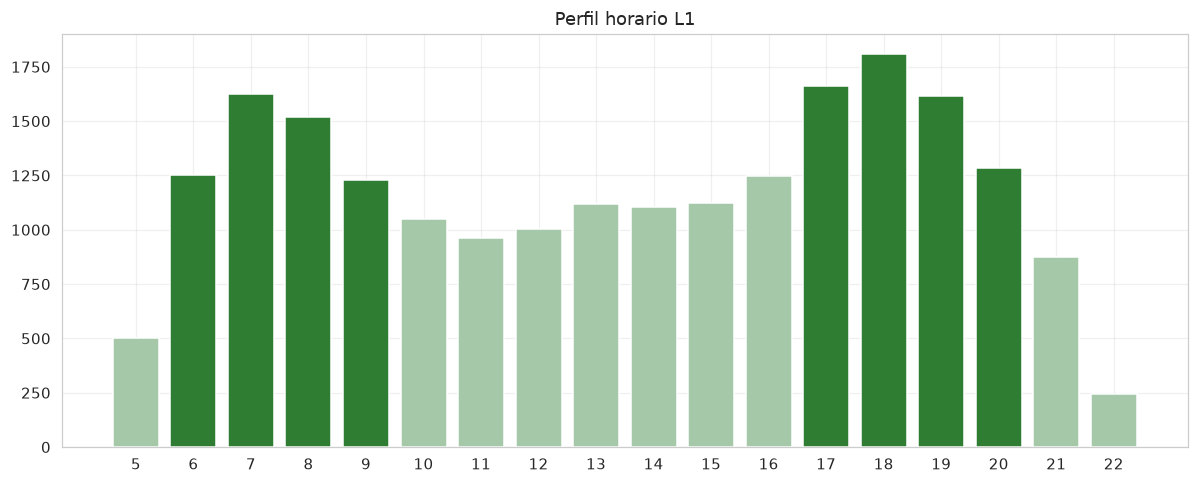

  [figura] docs/images/eda_l1_perfil_horario.png
dia_semana
LUN    22665.0
MAR    22813.0
MIÉ    22296.0
JUE    22134.0
VIE    23230.0
SÁB    22909.0
DOM    12573.0
SÁB/LUN=1.01 | DOM/LUN=0.55
                    validaciones  dias  share_%
estacion                                       
Gamarra               20057626.0   365     10.0
La Cultura            17373260.0   365      9.0
Bayóvar               17149456.0   365      8.0
Miguel Grau           13998774.0   365      7.0
Villa El Salvador     13549192.0   365      7.0
Angamos               10901613.0   365      5.0
Caja de Agua           9320069.0   365      5.0
Atocongo               7924565.0   365      4.0
Cabitos                7649086.0   365      4.0
Villa Maria            7093000.0   365      4.0
Nicolas Arriola        7015452.0   365      4.0
Maria Auxiliadora      6451741.0   365      3.0
San Carlos             6328538.0   365      3.0
Piramides del Sol      6152812.0   365      3.0
San Martin             5959188.0   365 

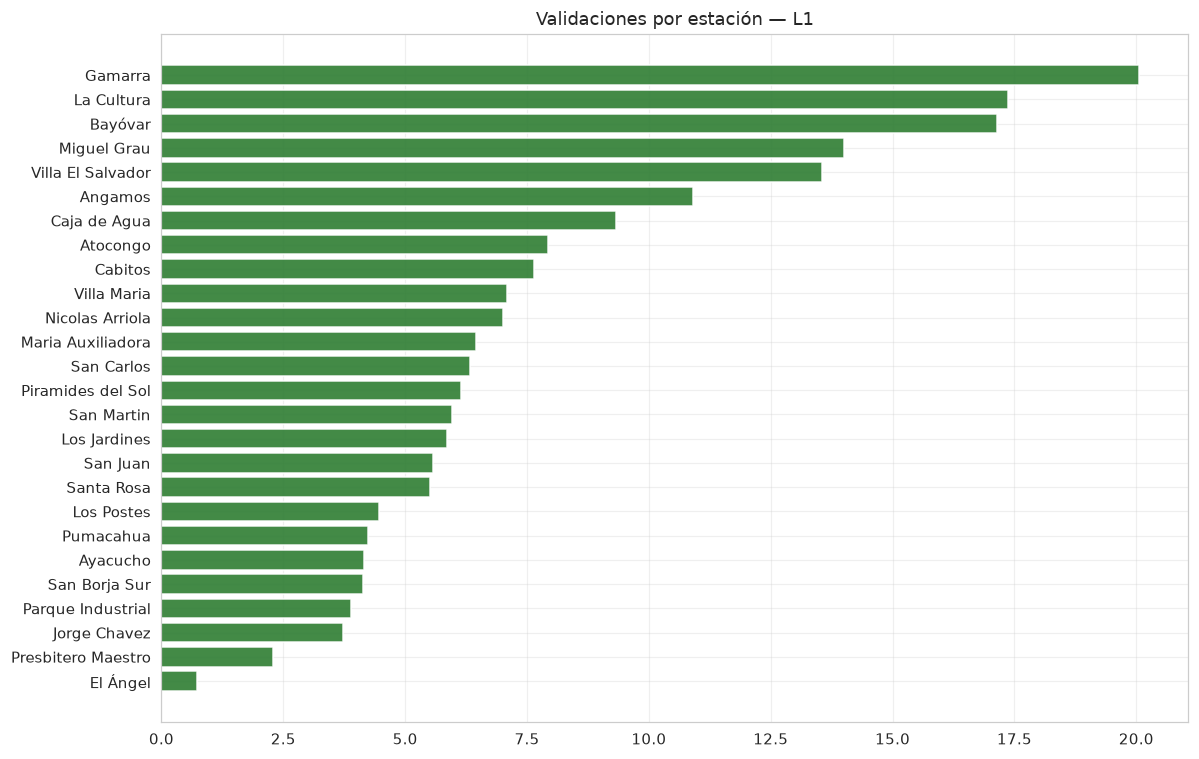

  [figura] docs/images/eda_l1_ranking_estaciones.png


In [25]:
perfil = d.groupby("hora")["validaciones"].mean()
pct = 100 * perfil / perfil.sum()
print(perfil.nlargest(5).round(0).to_string())
print(f"06-10h {pct[(pct.index>=6)&(pct.index<=10)].sum():.1f}% | 16-20h {pct[(pct.index>=16)&(pct.index<=20)].sum():.1f}%")
fig, ax = plt.subplots(figsize=(11, 4.5))
cols = [COLOR if (6<=h<=9 or 17<=h<=20) else "#a5c9a8" for h in perfil.index]
ax.bar(perfil.index, perfil.values, color=cols, width=0.8)
ax.set_xticks(range(5, 23)); ax.set_title("Perfil horario L1")
guardar_fig("eda_l1_perfil_horario.png")

est_dia = d.groupby(["fecha","estacion","dia_semana"])["validaciones"].sum().reset_index()
por_dia = est_dia.groupby("dia_semana")["validaciones"].mean().reindex(ORDEN_DIAS)
print(por_dia.round(0).to_string())
print(f"SÁB/LUN={por_dia['SÁB']/por_dia['LUN']:.2f} | DOM/LUN={por_dia['DOM']/por_dia['LUN']:.2f}")

por_est = (d.groupby("estacion").agg(validaciones=("validaciones","sum"), dias=("fecha","nunique"))
           .sort_values("validaciones", ascending=False))
por_est["share_%"] = (100*por_est["validaciones"]/por_est["validaciones"].sum()).round(1)
print(por_est.round(0).to_string())
fig, ax = plt.subplots(figsize=(11, 7))
top = por_est.sort_values("validaciones")
ax.barh(top.index, top["validaciones"]/1e6, color=COLOR, alpha=0.9)
ax.set_title("Validaciones por estación — L1")
guardar_fig("eda_l1_ranking_estaciones.png")


### 6.3 Tarifas (sin domingos en el % universitario)


tipo_tarifa
Adulto           94.64
Universitario     5.36


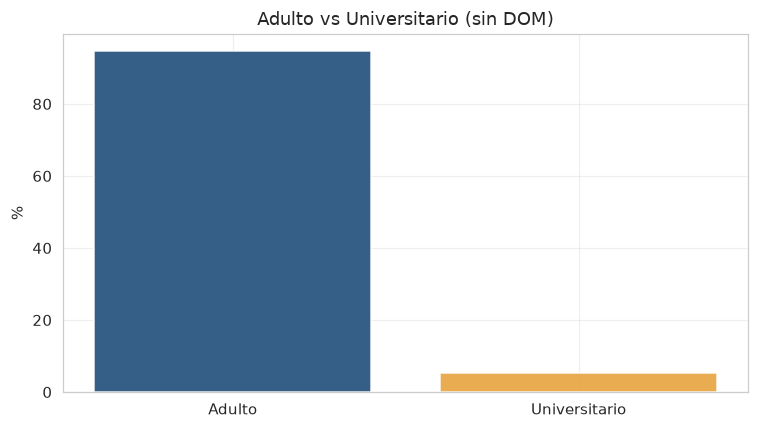

  [figura] docs/images/eda_l1_tarifas.png


In [26]:
tarifas = df[df["tipo_dia"] != "DOM"]
por_tarifa = (tarifas.groupby("tipo_tarifa")["validaciones"].sum() / tarifas["validaciones"].sum() * 100).round(2)
print(por_tarifa.to_string())
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(por_tarifa.index, por_tarifa.values, color=["#1f4e79", "#e8a33d"], alpha=0.9)
ax.set_ylabel("%"); ax.set_title("Adulto vs Universitario (sin DOM)")
guardar_fig("eda_l1_tarifas.png")


### 6.4 Correlación (estación × día)


                 val_dia  hora_media_pond  n_horas    mes    dow  es_feriado_i
val_dia            1.000            0.247      NaN  0.035 -0.145        -0.099
hora_media_pond    0.247            1.000      NaN  0.001  0.092         0.056
n_horas              NaN              NaN      NaN    NaN    NaN           NaN
mes                0.035            0.001      NaN  1.000 -0.008         0.038
dow               -0.145            0.092      NaN -0.008  1.000         0.008
es_feriado_i      -0.099            0.056      NaN  0.038  0.008         1.000


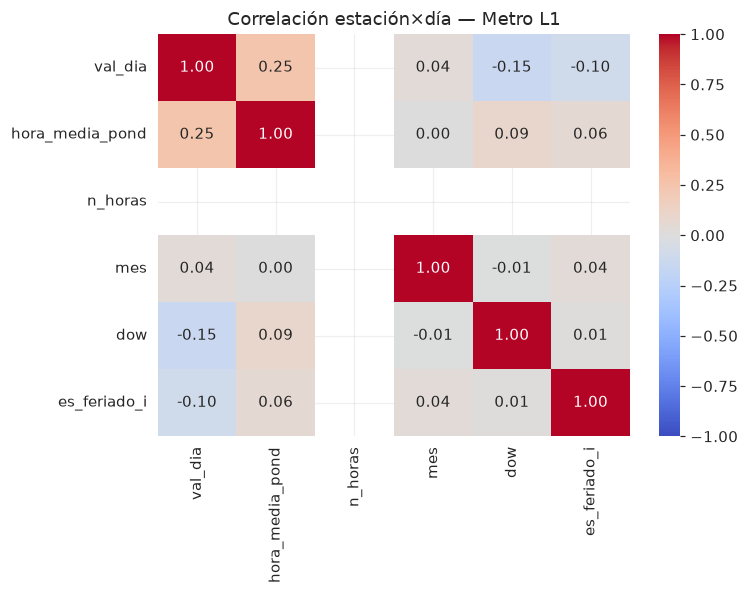

  [figura] docs/images/eda_l1_correlacion.png


In [27]:
tmp = (d.groupby(["estacion","fecha"], as_index=False)
       .apply(lambda g: pd.Series({
           "val_dia": g["validaciones"].sum(),
           "hora_media_pond": np.average(g["hora"].astype(float), weights=g["validaciones"]),
           "n_horas": g["hora"].nunique(),
       }), include_groups=False).reset_index(drop=True))
feat = d.groupby(["estacion","fecha","dia_semana","mes","es_feriado"], as_index=False).size().drop(columns="size")
feat = feat.merge(tmp, on=["estacion","fecha"])
feat["es_feriado_i"] = feat["es_feriado"].astype(int)
feat["dow"] = feat["dia_semana"].map({x:i for i,x in enumerate(DIAS)})
cols = ["val_dia","hora_media_pond","n_horas","mes","dow","es_feriado_i"]
corr = feat[cols].corr()
print(corr.round(3).to_string())
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación estación×día — Metro L1")
guardar_fig("eda_l1_correlacion.png")


### Decisión missingness (panel para ML)

- **NA (celda vacía Excel)** → `validaciones = 0` + `era_celda_vacia = True` (cero estructural de reporte; **no** KNN).
- **Cero escrito** → se **conserva** (señal real de nula demanda).
- Plots de cola/IQR pueden filtrar `validaciones > 0` sin borrar el panel.
- Así el modelo de abordar/esperar/cambiar aprende también cuándo un paradero está vacío.


## Mapa de demanda (Folium)

Misma lógica que el EDA TransMilenio (week07): elige `nivel` = `dia` | `dow` | `hora`.

Puntos desde `data/fuentes/geo/`; trazado LineString/shp cuando existe.
Los NA del Excel ya están como **0 + `era_celda_vacia`** en el panel (no sesgamos borrando ceros).


In [28]:
import sys
import importlib
sys.path.insert(0, str(RAIZ / "code" / "scripts"))
import eda_geo_maps
importlib.reload(eda_geo_maps)
from eda_geo_maps import load_puntos, load_trazado_path, mapa_demanda, find_mapa_atu_corredor, find_mapa_atu_metro

GEO = RAIZ / "data" / "fuentes" / "geo"
FUENTES = RAIZ / "data" / "fuentes"
MAPS = RAIZ / "docs" / "maps"
MAPS.mkdir(parents=True, exist_ok=True)
print("GeoJSON en", GEO)
print("eda_geo_maps:", eda_geo_maps.__file__)
print(list(GEO.glob("*.geojson")))


GeoJSON en /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo
eda_geo_maps: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/code/scripts/eda_geo_maps.py
[PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_metro_l1.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazado_metro_l1.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_corredores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazados_corredores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_troncal.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazado_troncal.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_alimentadores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/D

In [29]:
# --- parámetros del mapa (editar y re-ejecutar) ---

nivel = "dow"           # "dia" | "dow" | "hora"

fecha = "2025-07-15"    # si nivel == "dia"

dia_sem = "MAR"         # si nivel == "dow"  (LUN..DOM)

hora = 8                # si nivel == "hora"



puntos = load_puntos(GEO, "metro_l1")

trazado = load_trazado_path(GEO, "metro_l1")

print("puntos:", len(puntos), "| trazado:", trazado)



# para el mapa usamos el panel (incluye ceros); agrega coords

_df_map = d.copy()

if "estacion" != "unidad":

    pass



m = mapa_demanda(

    _df_map, puntos,

    unidad_col="estacion",

    trazado=trazado,

    nivel=nivel, fecha=fecha, dia_sem=dia_sem, hora=hora,

    color_linea="#2e7d32",

    save_html=MAPS / "mapa_metro_l1.html",

)

from IPython.display import display

display(m)  # se renderiza inline en la celda (como week07)



puntos: 26 | trazado: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazado_metro_l1.geojson
Viendo total de todos los MAR del periodo: 24,336 filas, 30,843,144 validaciones
Unidades en mapa: 22 / 26 con demanda en la selección (84.6% geocodificadas)
  [mapa] /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/docs/maps/mapa_metro_l1.html


### 6.5 Conclusiones

1. L1 es la referencia de calidad (cobertura 100%, 26 estaciones).
2. El **sábado ≈ laborable**; el domingo cae ~45%.
3. Usar totales sin tarifa para series; el % universitario excluye DOM.
4. Outliers IQR se conservan.
5. Salidas: `metro_l1_hora.parquet` + `metro_l1_total_hora.parquet`.


In [30]:
# total con features
cols_tot = ["fecha","anio","mes","dia_semana","tipo_dia","semana_iso","feriado","es_feriado",
            "estacion","hora","franja","validaciones","log_val","es_outlier_iqr", "era_celda_vacia"]
d[cols_tot].sort_values(["fecha","estacion","hora"]).to_parquet(
    CLEAN / "metro_l1_total_hora.parquet", index=False, compression="snappy")

# con tarifa + calendario
df["franja"] = marcar_franja(df["hora"])
df["log_val"] = np.log1p(df["validaciones"])
# map outlier from total-day
df = df.merge(diario[["estacion","fecha","es_outlier_iqr"]], on=["estacion","fecha"], how="left")
cols_m = ["fecha","anio","mes","dia_semana","tipo_dia","semana_iso","feriado","es_feriado",
          "estacion","hora","intervalo","tipo_tarifa","franja","validaciones","log_val","es_outlier_iqr", "era_celda_vacia"]
df[cols_m].sort_values(["fecha","estacion","hora","tipo_tarifa"]).to_parquet(
    CLEAN / "metro_l1_hora.parquet", index=False, compression="snappy")
print("metro_l1_hora y metro_l1_total_hora escritos")
cob.rename(columns={"estacion":"unidad"}).assign(sistema="metro_l1").to_csv(
    CLEAN / "calidad_cobertura_metro_l1.csv", index=False)


metro_l1_hora y metro_l1_total_hora escritos
